In [1]:
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
import numpy as np
import json

from torch.utils.data import DataLoader

from os import listdir
from os.path import isfile, join

import VAE


In [2]:
device = torch.device("mps")

In [3]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [4]:
class CIFAR_DataLoader(torch.utils.data.Dataset):

    def __init__(self,dir,device):
        self.files = [f for f in listdir(dir) if isfile(join(dir, f))]
        self.Data = torch.tensor([])
        self.Labels = torch.tensor([])
        self.testData =torch.tensor([])
        self.testLabel =torch.tensor([])
        for file in self.files:
            #print(file)
            if "data" in file:
                tempData = unpickle(f"{dir}/{file}")

                self.Labels = torch.cat((self.Labels,torch.tensor(tempData[b"labels"])),0)

                self.Data = torch.cat((self.Data,torch.tensor(tempData[b"data"])),0)
    
            elif "test" in file:
                pass
        #print(self.Data.shape)
        
        self.Data = self.Data.reshape(self.Data.shape[0],3,32,32)
        self.Data = self.Data.to(torch.float32)
        #print(self.Data.shape)
        self.Data = (self.Data / 127.5) - 1
    def __len__(self):
        return self.Labels.shape[0]
        
    def __getitem__(self,index):
        return self.Data[index] , self.Labels[index]



In [5]:

batch_size = 128
Data = CIFAR_DataLoader("cifar-10-batches-py",device)
train_dataloader = DataLoader(Data, batch_size=batch_size, shuffle=True)


/var/folders/_8/5q7jkgdx3fx_kvr5tnf9v5s80000gn/T/ipykernel_12071/2560472653.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


In [6]:
X,Y= next(iter(train_dataloader))
latentDim =32
Model = VAE.VAE(latentDim,device).to(device)

In [7]:
G = np.arange(0,256)
print(max((G/127.5 - 1)))

1.0


In [8]:

criterion = nn.MSELoss(reduction="sum")
optimizer = torch.optim.Adam(Model.parameters(), lr=2e-4, betas=(0.9, 0.999))

In [ ]:
epochs = 200

losses = []
kls = []
rls = []

for ep in range(epochs):

    for i, data in enumerate(train_dataloader):
        optimizer.zero_grad()
        X = data[0].to(device)
        O , u , log_s = Model(X)
        kl = - ((0.5 * torch.sum(1 + (2*log_s) - (u**2) - torch.exp(2*log_s) ))/ X.size(0))
        rl = (criterion(O,X)/ X.size(0)) 
        loss = rl+kl
        
        loss.backward()
        optimizer.step()
        
        
        if i % batch_size == 0:
            losses.append(loss.item())
            rls.append(rl)
            kls.append(kl)
            print("==========================")
            print(f"Epoch {ep} : Step {i} \n: VAE_loss {loss.item()} : KL div {kl} : Recon {rl}")
            print("==========================")

Epoch 0 : Step 0 
: VAE_loss 1892.913818359375 : KL div -12.63287353515625 : Recon 1905.546630859375
Epoch 0 : Step 128 
: VAE_loss nan : KL div nan : Recon 835.0380859375
Epoch 0 : Step 256 
: VAE_loss nan : KL div nan : Recon 773.6092529296875


KeyboardInterrupt: 

In [ ]:
d = torch.load("Model_500epoch_128ld.pth", weights_only=True,map_location=torch.device('mps'))
print(d)

OrderedDict({'Encoder.M1.0.weight': tensor([[[[-0.0427,  0.0496, -0.0665,  0.1808, -0.6713],
          [ 0.0063, -0.0198,  0.0435,  0.2004, -0.5367],
          [-0.1117, -0.0468, -0.1992,  0.1598, -0.7380],
          [ 0.3237,  0.4917,  0.4670,  0.8931,  0.0421],
          [-0.6280, -0.4385, -0.1698,  0.2785, -2.0403]],

         [[ 0.1197,  0.0243, -0.0652,  0.3756, -0.1159],
          [ 0.0242,  0.0231,  0.0291,  0.3144, -0.0478],
          [-0.1623, -0.1385, -0.2131,  0.1819, -0.2131],
          [ 0.2942,  0.3979,  0.3689,  0.8145,  0.3792],
          [-0.2530, -0.0766, -0.0089,  0.2865, -1.2589]],

         [[-0.1589,  0.0791, -0.1211, -0.0332, -0.1005],
          [-0.0523,  0.0338,  0.1535,  0.0919, -0.1112],
          [-0.2090, -0.0810, -0.1111,  0.0548, -0.3045],
          [ 0.1581,  0.3445,  0.2802,  0.3941,  0.2509],
          [-0.4951, -0.3843, -0.2579, -0.1369, -1.1662]]],


        [[[-0.0893, -0.0789, -0.1035, -0.0368, -0.3216],
          [-0.0682, -0.0193, -0.0644, -0.057

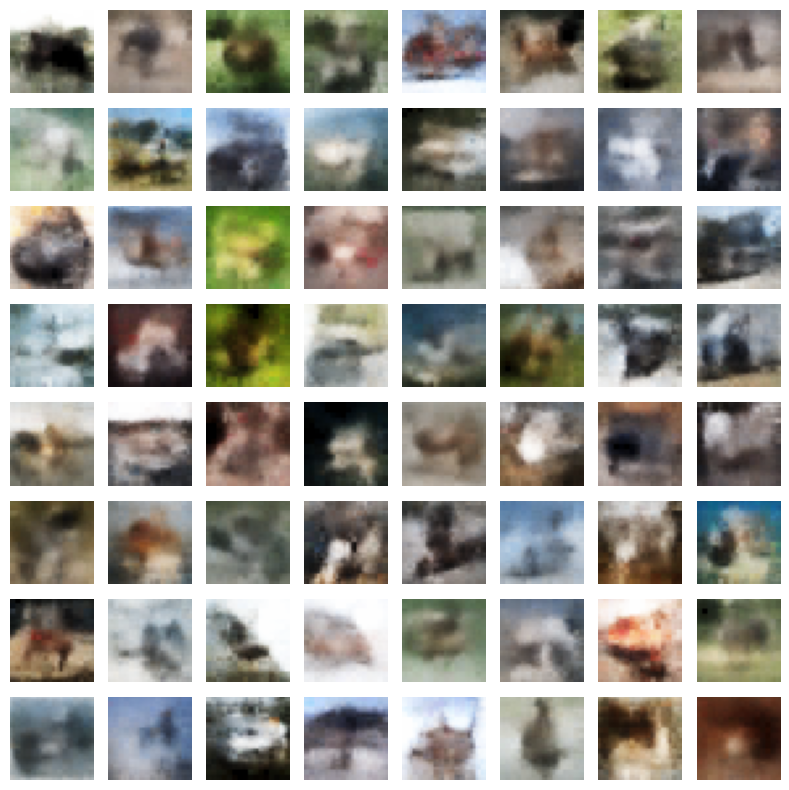

In [ ]:
Z = torch.randn((64, latentDim), device=device)
load = True
Model.load_state_dict(torch.load("Model_500epoch_128ld.pth", weights_only=True,map_location=torch.device('mps')))
    
with torch.no_grad():
    fakes = Model.Decoder(Z)

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i in range(64):
    row = i // 8
    col = i % 8
    img = fakes[i].detach().cpu()
    img = img.permute(1, 2, 0)
    img = (img + 1) / 2
    img = img.clamp(0, 1).numpy()
    axes[row, col].imshow(img)
    axes[row, col].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
torch.save(Model.state_dict(), 'model_weights.pth')

with open("losses.json", "w") as fp:
    json.dump(losses, fp)
with open("kls.json", "w") as fp:
    json.dump(kls, fp)
with open("rls.json", "w") as fp:
    json.dump(rls, fp)